In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import contextily as cx
from pyproj import CRS, Transformer

import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle
from python.model_wrapper import *
%load_ext autoreload
%autoreload 2

In [2]:
model_path = Path.cwd().parent / 'model'
mask_geojson = r'f:\TUD_CEG_Repository\MSc_Thesis\Code\model\input\mozambique\land_mask_mozambique.geojson'
yaml_path = os.path.join(model_path,'data_catalog.yml')

res = 10
dy, dx = res, res


xmin, ymin, xmax, ymax = 34.4209678721728238, -20.4210371638252077 , 34.9790781614015955, -20.0997273196721835

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32736", always_xy=True)
xmin_utm, ymin_utm = transformer.transform(xmin, ymin)
xmax_utm, ymax_utm = transformer.transform(xmax, ymax)
print(xmin_utm, ymin_utm,xmax_utm, ymax_utm)

648253.0413725708 7741284.07251886 706922.8771330751 7776254.339515453


In [3]:
hmaxs = []
for fn in os.listdir(model_path):
    if 'yy' in fn:
        print(fn)
        model_root = model_path / fn
        hmax, _ = post_process_output(model_root,yaml_path,mask_geojson=mask_geojson,plot_image=False)
        hmax = hmax.rio.clip_box(
            minx=xmin_utm,
            miny=ymin_utm,
            maxx=xmax_utm,
            maxy=ymax_utm
        )
        hmaxs.append(hmax)

yy1_mozambique_flood_subgrid
2026-07-08 09:18:32,859 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from f:\TUD_CEG_Repository\MSc_Thesis\Code\model\data_catalog.yml
2026-07-08 09:18:33,072 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-07-08 09:18:33,073 - hydromt.model.model - model - WARNING - No region component found in components.
2026-07-08 09:18:33,631 - hydromt.hydromt_sfincs.components.output - output - WARNING - File F:\TUD_CEG_Repository\MSc_Thesis\Code\model\yy1_mozambique_flood_subgrid\sfincs_his.nc not found.
2026-07-08 09:18:33,632 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-07-08 09:18:33,633 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-07-08 09:18:33,633 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zb
2026-07-08 09:18:33,634 - hydromt.hydromt_sfincs.co

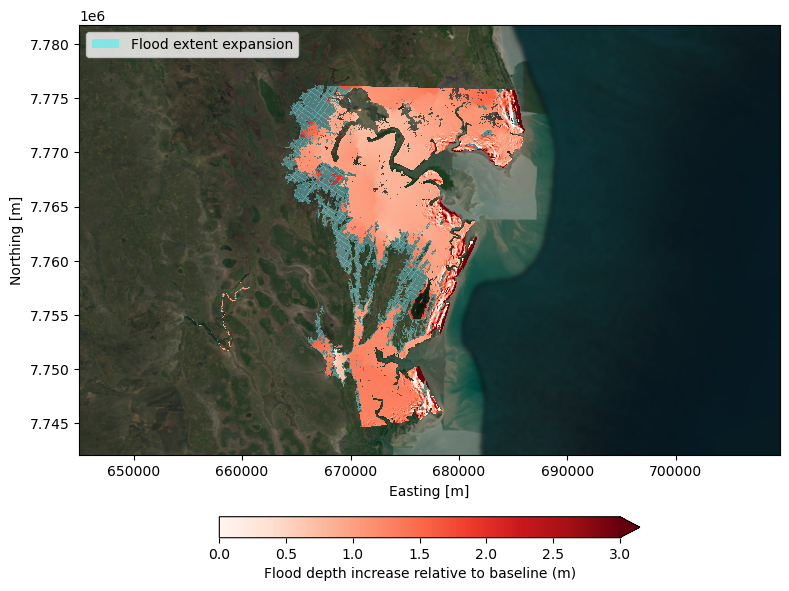

In [4]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8,8))

crs = CRS.from_user_input(hmax.rio.crs)


hmax_base = hmaxs[0]
hmax_combined_100 = hmaxs[6]

ax.pcolormesh(
    hmax["xc"],
    hmax["yc"],
    hmax_combined_100.where(hmax_combined_100 > 0),
    cmap=ListedColormap(["#7FE7F5"]),
    shading="auto",
    alpha=0.4,
    zorder=3,
)

pct_change = xr.where(
    hmax_base > 0,
    (hmax_combined_100 - hmax_base) / hmax_base * 100,
    np.nan,
)

pcm = ax.pcolormesh(
    hmax["xc"],
    hmax["yc"],
    hmax_combined_100 - hmax_base,
    cmap="Reds",
    shading="auto",
    vmin=0,
    vmax=3,
    zorder=4,
)

cbar = plt.colorbar(
    pcm,
    ax=ax,
    extend="max",          # <-- triangular top
    shrink=0.6,
    pad=0.08,
    orientation='horizontal',
    label="Flood depth increase relative to baseline (m)"
    # anchor = (0.1, 0.1)
)

# Add satellite beneath it
cx.add_basemap(
    ax,
    crs=hmax.rio.crs,
    source=cx.providers.Esri.WorldImagery,
    attribution=False,
    zoom=13,
    zorder=1,
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

rect = Rectangle(
    (xmin, ymin),
    xmax - xmin,
    ymax - ymin,
    facecolor='black',
    alpha=0.3,      # adjust between 0.1–0.3
    zorder=2
)

ax.add_patch(rect)

legend_elements = [
    Patch(facecolor='cyan', edgecolor='none',
          alpha = 0.4,
          label='Flood extent expansion')
]



ax.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=True
)

ax.set_xlabel(f'Easting [m]')
ax.set_ylabel(f'Northing [m]')
# plt.colorbar(pcm, ax=ax, label="Flood depth (m)")
ax.set_aspect("equal")
plt.tight_layout()

In [5]:



def plot_flood_change_panel(
    ax,
    hmax_base,
    hmax_scenario,
    title,
    vmin=0,
    vmax=2,
    zoom=13,
    add_basemap=True,
):
    # New inundation only:
    # flooded in scenario, dry in baseline
    new_extent = hmax_scenario.where(
        (hmax_scenario > 0) & ((hmax_base <= 0) | np.isnan(hmax_base))
    )

    # Depth increase only in baseline flooded area
    depth_increase = xr.where(
        (hmax_base > 0) & (hmax_scenario > hmax_base),
        hmax_scenario - hmax_base,
        np.nan,
    )

    # Flood extent expansion
    ax.pcolormesh(
        hmax_scenario["xc"],
        hmax_scenario["yc"],
        new_extent,
        cmap=ListedColormap(["#7FE7F5"]),
        shading="auto",
        alpha=0.45,
        zorder=3,
    )

    # Flood depth increase
    pcm = ax.pcolormesh(
        hmax_scenario["xc"],
        hmax_scenario["yc"],
        depth_increase,
        cmap="Reds",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=4,
    )

    # Satellite basemap
    if add_basemap:
        crs = hmax_base.rio.crs
        cx.add_basemap(
            ax,
            crs=crs,
            source=cx.providers.Esri.WorldImagery,
            attribution=False,
            zoom=zoom,
            zorder=1,
        )

        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        rect = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            facecolor="black",
            alpha=0.35,
            zorder=2,
        )
        ax.add_patch(rect)

    ax.set_title(title, fontsize=12, fontweight="bold", color="#0070C0")
    ax.set_aspect("equal")
    ax.set_xlabel("Easting [m]")
    ax.set_ylabel("Northing [m]")

    return pcm

In [6]:
def plot_flood_map(
    ax,
    hmax,
    title,
    vmin=0,
    vmax=2,
    zoom=13,
    add_basemap=True,
):


    # Flood depth increase
    pcm = ax.pcolormesh(
        hmax["xc"],
        hmax["yc"],
        hmax,
        cmap="Blues",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        zorder=4,
    )

    # Satellite basemap
    if add_basemap:
        crs = hmax_base.rio.crs
        cx.add_basemap(
            ax,
            crs=crs,
            source=cx.providers.Esri.WorldImagery,
            attribution=False,
            zoom=zoom,
            zorder=1,
        )

        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        rect = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            facecolor="black",
            alpha=0.35,
            zorder=2,
        )
        ax.add_patch(rect)

    ax.set_title(title, fontsize=12, fontweight="bold", color="#0070C0")
    ax.set_aspect("equal")
    ax.set_xlabel("Easting [m]")
    ax.set_ylabel("Northing [m]")

    return pcm

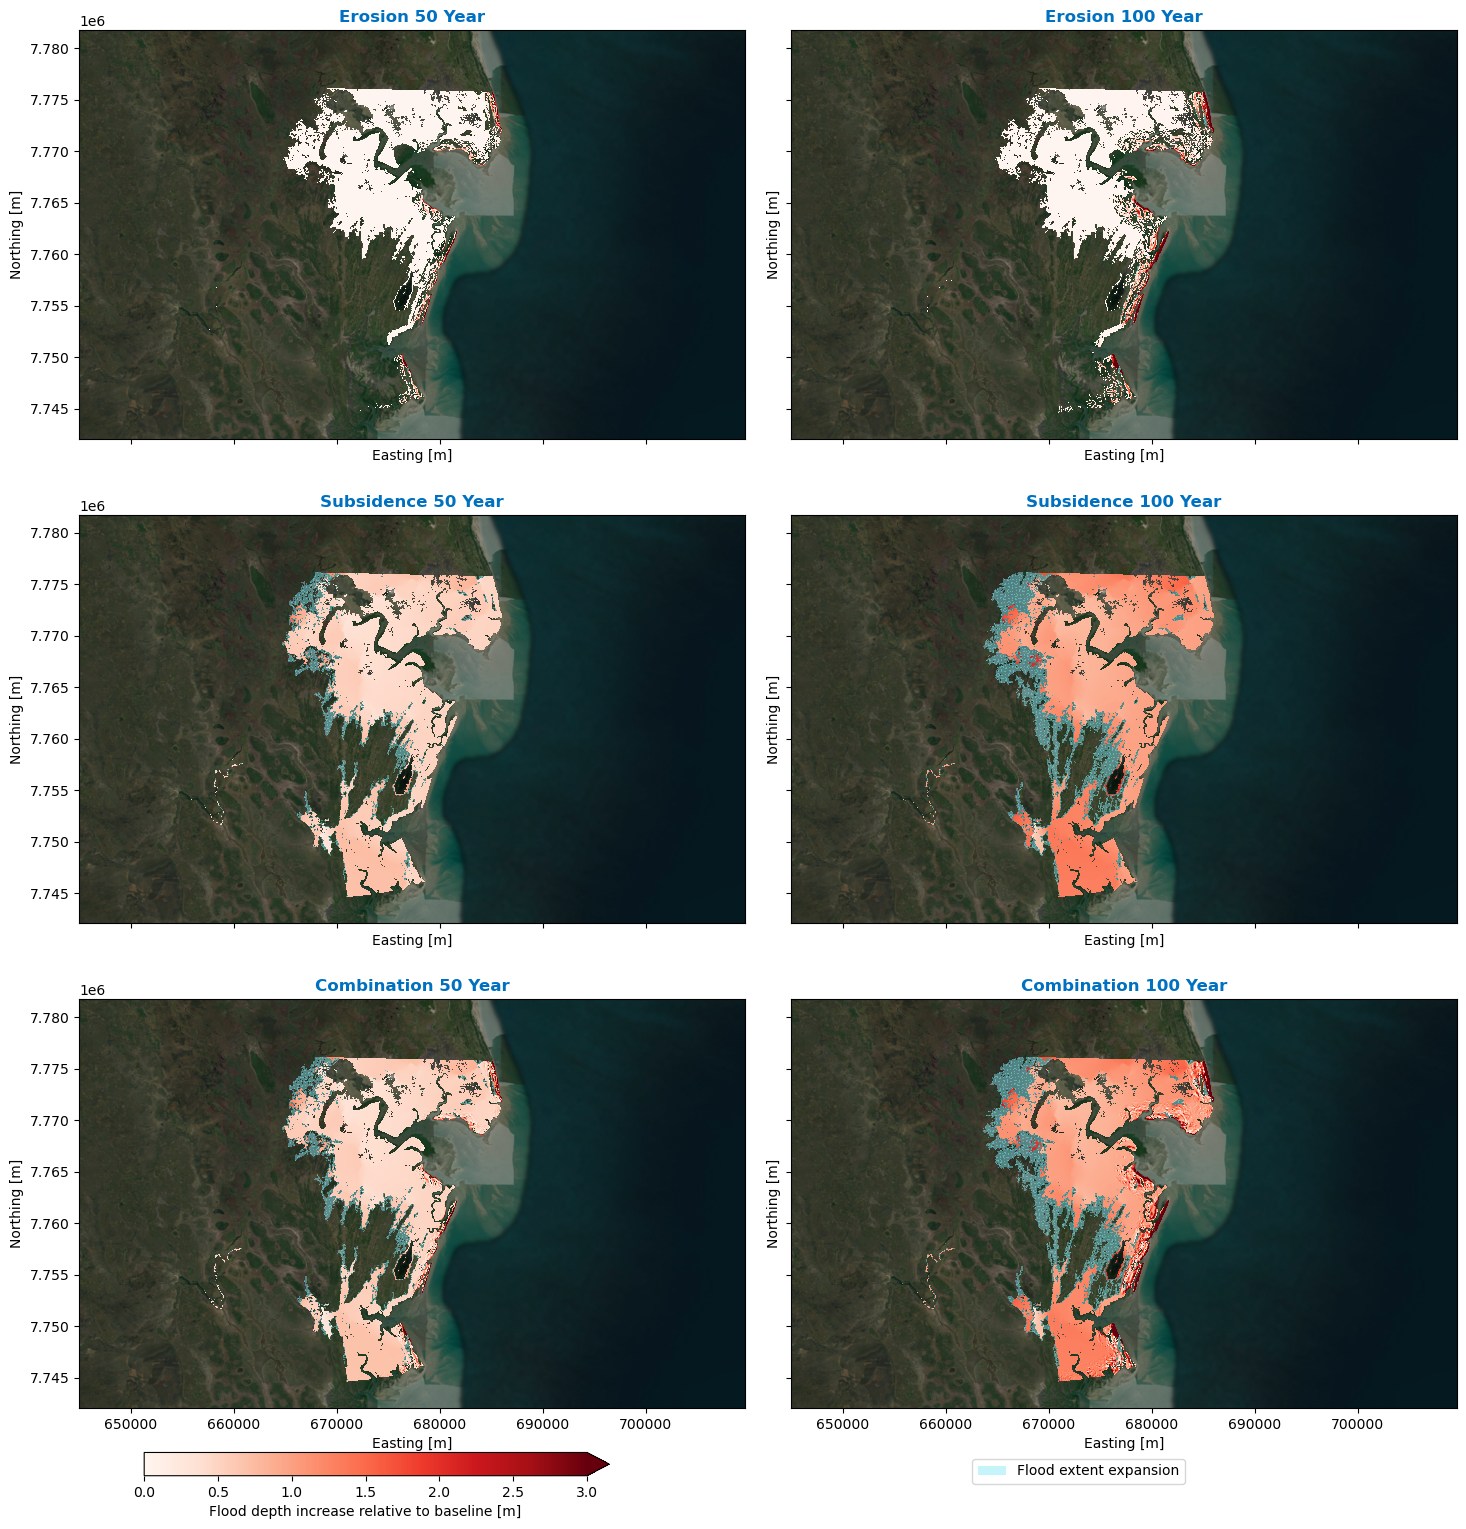

In [13]:
hmax_base = hmaxs[0]
scenarios = {
    "Erosion 50 Year": hmaxs[1],
    "Erosion 100 Year": hmaxs[2],
    "Subsidence 50 Year": hmaxs[3],
    "Subsidence 100 Year": hmaxs[4],
    "Combination 50 Year": hmaxs[5],
    "Combination 100 Year": hmaxs[6],
}

crs = hmax_base.rio.crs

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 17),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

i = 1
for ax, (title, hmax_scenario) in zip(axes, scenarios.items()):
    pcm = plot_flood_change_panel(
        ax=ax,
        hmax_base=hmax_base,
        hmax_scenario=hmax_scenario,
        title=title,
        vmin=0,
        vmax=3,
        zoom=13,
    )
    # pcm = plt.plot(ax=ax)
    # if i>2:
    #     break
    # else:
    #     i += 1

# One shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=axes,
    orientation="horizontal",
    extend="max",
    shrink=0.4,
    pad=0.06,
    # anchor = (-0.05, -1.5)
    anchor = (-0.05, -0.6)
)

cbar.set_label("Flood depth increase relative to baseline [m]")

# One shared legend
legend_elements = [
    Patch(
        facecolor="#7FE7F5",
        edgecolor="none",
        alpha=0.45,
        label="Flood extent expansion"
    )
]

fig.legend(
    handles=legend_elements,
    loc="lower right",
    # bbox_to_anchor=(0.8, -0.01),
    bbox_to_anchor=(0.8, 0.04),
    frameon=True,
    ncol=1
)

# fig.suptitle(
#     "Flood amplification relative to baseline",
#     fontsize=18,
#     fontweight="bold"
# )

plt.tight_layout(rect=[0, 0.08, 1, 0.92])

# plt.savefig(
#     "flood_change_panel.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

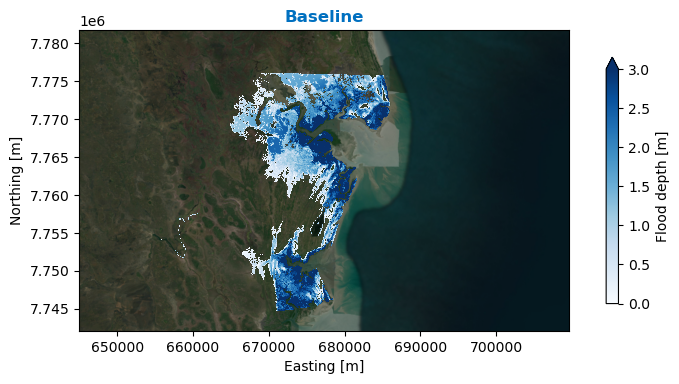

In [8]:
fig,ax = plt.subplots(figsize=(8,8))



pcm = plot_flood_map(
    ax,
    hmax_base,
    'Baseline',
    vmin=0,
    vmax=3,
    zoom=13,
    add_basemap=True,
)

# One shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=ax,
    # orientation="horizontal",
    extend="max",
    shrink=0.4,
    pad=0.06,
    anchor = (0, 0.5)
)

cbar.set_label("Flood depth [m]")

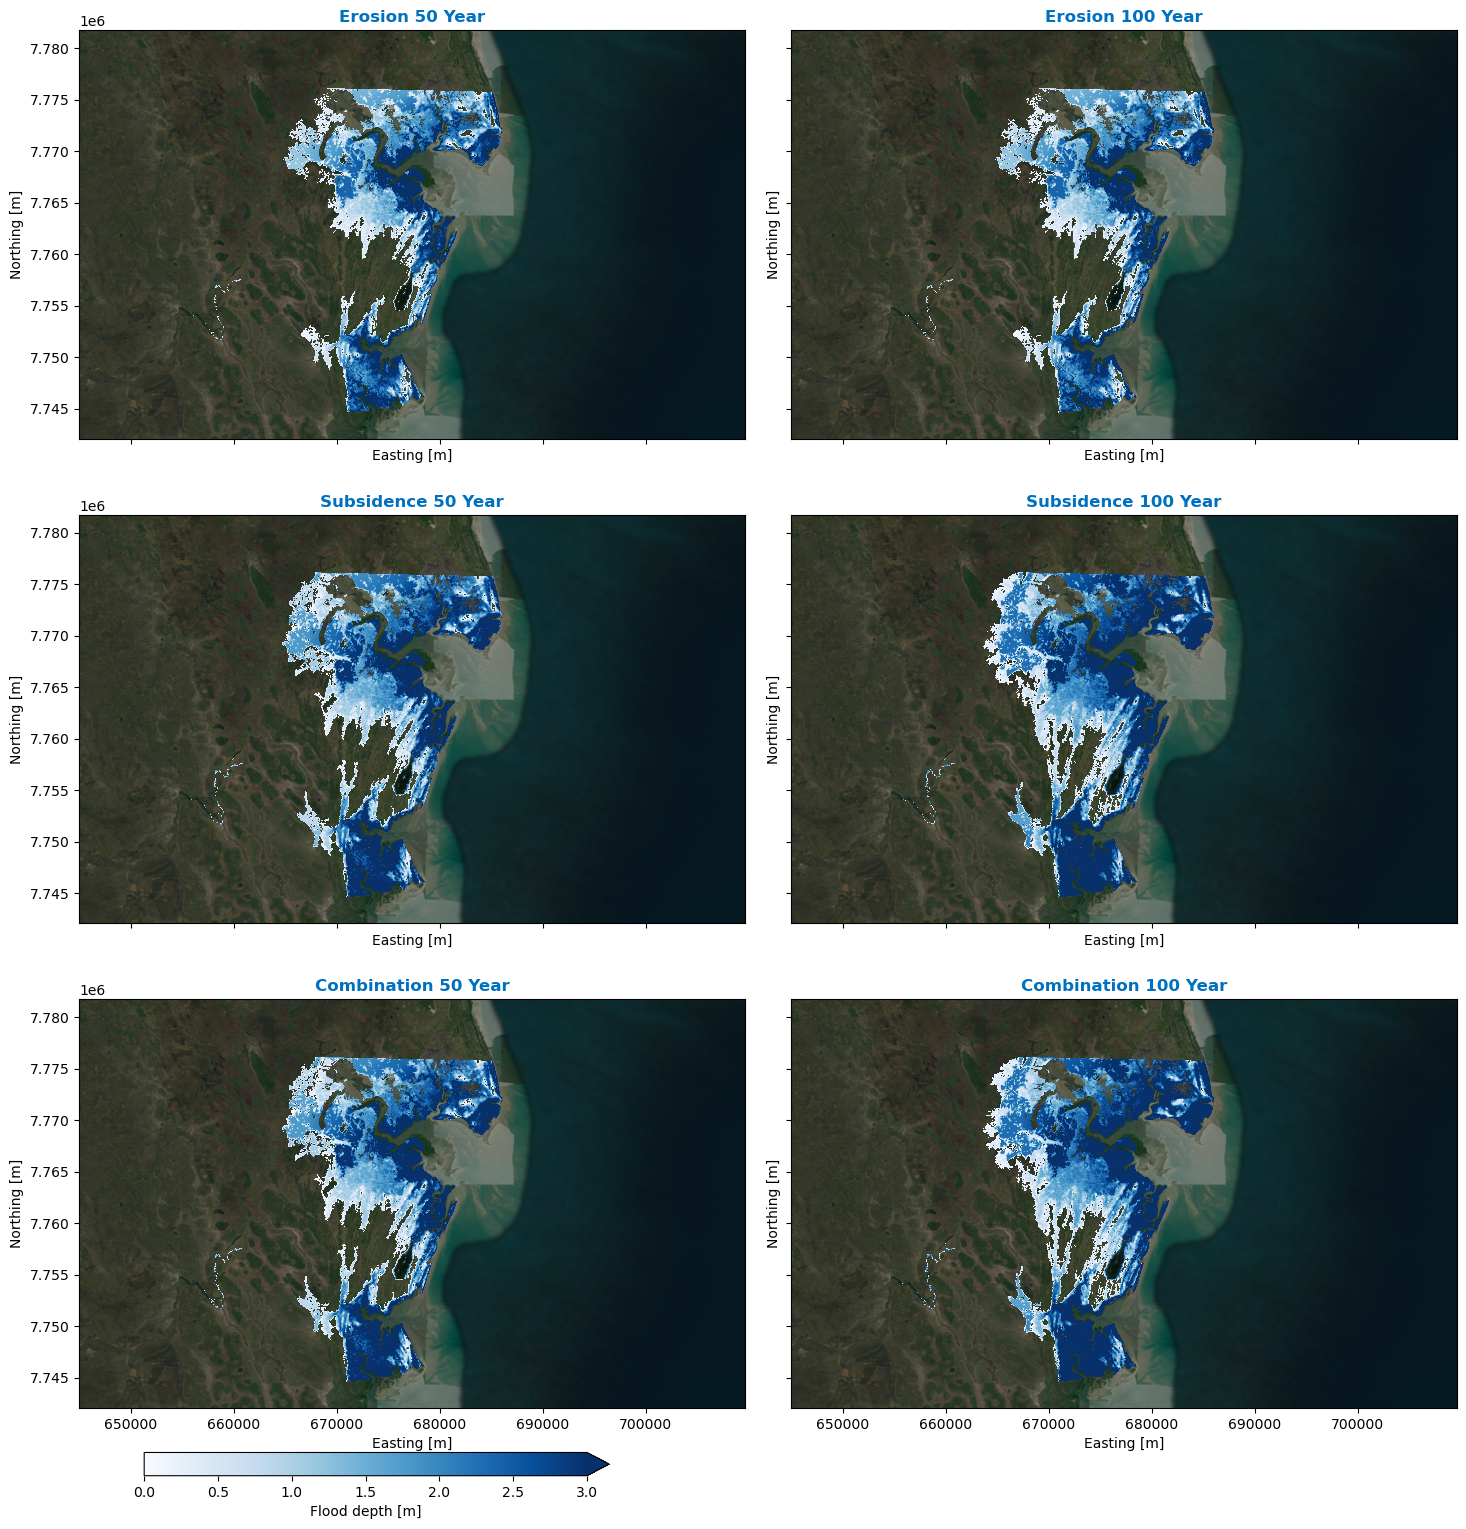

In [12]:
hmax_base = hmaxs[0]
scenarios = {
    "Erosion 50 Year": hmaxs[1],
    "Erosion 100 Year": hmaxs[2],
    "Subsidence 50 Year": hmaxs[3],
    "Subsidence 100 Year": hmaxs[4],
    "Combination 50 Year": hmaxs[5],
    "Combination 100 Year": hmaxs[6],
}

crs = hmax_base.rio.crs

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 17),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

i = 1
for ax, (title, hmax_scenario) in zip(axes, scenarios.items()):
    pcm = plot_flood_map(
        ax,
        hmax_scenario,
        title=title,
        vmin=0,
        vmax=3,
        zoom=13,
    )
    # pcm = plt.plot(ax=ax)
    # if i>2:
    #     break
    # else:
    #     i += 1

# One shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=axes,
    orientation="horizontal",
    extend="max",
    shrink=0.4,
    pad=0.06,
    # anchor = (-0.05, -1.5)
    anchor = (-0.05, -0.6)
)

cbar.set_label("Flood depth [m]")

# fig.suptitle(
#     "Flood amplification relative to baseline",
#     fontsize=18,
#     fontweight="bold"
# )

plt.tight_layout(rect=[0, 0.08, 1, 0.92])

# plt.savefig(
#     "flood_change_panel.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [10]:
statistics = []

scenarios = {
    "Erosion 50 Year": hmaxs[1],
    "Erosion 100 Year": hmaxs[2],
    "Subsidence 50 Year": hmaxs[3],
    "Subsidence 100 Year": hmaxs[4],
    "Combination 50 Year": hmaxs[5],
    "Combination 100 Year": hmaxs[6],
}

stat = summarize_flood(hmax_base, 'Baseline', dx, dy)
statistics.append(stat)

for scenario, h in scenarios.items():
    stat = summarize_flood(h, scenario, dx, dy)
    statistics.append(stat)

10 10
10 10
10 10
10 10
10 10
10 10
10 10


In [11]:
df = pd.DataFrame(statistics)
# df.to_csv("flood_statistics_mozambique.csv", index=False)
df

,scenario,flooded_cells,flood_extent_m2,flood_extent_km2,mean_depth_m,max_depth_m,volume_m3
0,Baseline,2300270,230027000,230.0270,1.816042,5.534138,417738800.0
1,Erosion 50 Year,2300010,230001000,230.0010,1.835829,7.818748,422242600.0
2,Erosion 100 Year,2303392,230339200,230.3392,1.897448,8.745018,437056700.0
3,Subsidence 50 Year,2651340,265134000,265.1340,2.100544,6.015884,556925650.0
4,Subsidence 100 Year,3059386,305938600,305.9386,2.349417,6.494683,718777250.0
5,Combination 50 Year,2650820,265082000,265.0820,2.118137,8.318506,561479900.0
6,Combination 100 Year,3060597,306059700,306.0597,2.415442,9.746559,739269500.0
